In [ ]:
# INSTALLING **PACKAGES**


!pip install statsmodels

! pip install optuna

!pip install tabulate

# Standard libraries
import sys  # System-specific parameters and functions
import os   # Miscellaneous operating system interfaces
import warnings  # Warning control
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical operations

# Visualization
import matplotlib.pyplot as plt  # Plotting library
import seaborn as sns  # Statistical data visualization
from matplotlib.colors import ListedColormap  # Colormap utilities

# Model Helpers
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler  # Preprocessing tools
from sklearn import model_selection, metrics, preprocessing  # Model selection, evaluation, and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV  # Model selection and evaluation
from sklearn.tree import DecisionTreeClassifier  # Decision tree classifier


# Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor  # Variance inflation factor
from scipy.stats import pointbiserialr, chi2_contingency, spearmanr, entropy  # Statistical functions
from statsmodels.graphics.gofplots import qqplot  # Q-Q plot
from collections import Counter  # Container datatypes

# Tabulate
from tabulate import tabulate  # Pretty-print tabular data

# Set visualization style
#sns.set()  # Set Seaborn default style
#plt.style.use('ggplot')  # Set ggplot style for matplotlib



# LOADING THE DATA SET
#https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
#https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing
import gdown
import pandas as pd


# Read Xlsx file
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import pandas as pd
import numpy as np  # Ensure numpy is imported
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Read Xlsx file
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import pandas as pd
import numpy as np  # Ensure numpy is imported
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


import pandas as pd

# Updated Google Sheets link setup
sheet_id = "1j_Euo80PrGckVDVr2hTG9zZebxJD0TSC"
sheet_name = "Sheet1"  # Update this if the sheet name is different

# Generate the CSV export link
csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

# Read the Google Sheet as CSV
df = pd.read_csv(csv_url)

# Backup original DataFrame
df_backup = df.copy()


# Set Date as the index
df = df.set_index('Date')

# Display the DataFrame (optional in scripts)
df.head()
df_backup=df.copy()

df = df.drop(columns=["YEAR", "MO", "DY"])

df



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 9.0 MB/s eta 0:00:00


,PREC,SURF_PRESSSURE,MAX_TEMP,MIN_TEMP,RH,AVG_TEMP,SL_PRESSURE,CLOUD_COVER,WS10M,WD_sin,WD_cos,MONOSOON_SEASON_Northeast_Monsoon,MONOSOON_SEASON_Second_Inter_Monsoon,MONOSOON_SEASON_Southwest_Monsoon
Date,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.22,99.57,28.16,23.90,85.13,28.5,1009.2,5.0,3.99,0.600420,0.799685,True,False,False
2013-01-02 00:00:00,1.09,99.65,27.65,23.41,86.19,27.6,1010.4,5.0,4.25,0.500000,0.866025,True,False,False
2013-01-03 00:00:00,13.42,99.68,28.38,23.42,86.26,26.4,1011.0,8.0,4.75,0.439939,0.898028,True,False,False
2013-01-04 00:00:00,8.79,99.65,27.58,22.93,86.31,25.1,1010.1,8.0,5.74,0.424199,0.905569,True,False,False
2013-01-05 00:00:00,2.60,99.50,26.16,22.17,86.88,26.9,1007.5,8.0,5.79,0.563526,0.826098,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27 00:00:00,9.45,99.66,30.35,24.40,88.57,29.5,1011.0,5.0,6.43,0.381070,0.924546,True,False,False
2023-12-28 00:00:00,13.93,99.58,29.37,25.51,90.59,28.5,1010.9,7.0,3.93,0.634731,0.772734,True,False,False
2023-12-29 00:00:00,9.80,99.69,29.30,25.03,89.03,28.2,1011.4,7.0,2.59,0.689620,0.724172,True,False,False


In [ ]:
monsoon_cols=['MONOSOON_SEASON_Northeast_Monsoon',
       'MONOSOON_SEASON_Second_Inter_Monsoon',
       'MONOSOON_SEASON_Southwest_Monsoon']
df[monsoon_cols]=df[monsoon_cols].astype(int)

In [ ]:

# Define the number of lag terms
num_lags = 14

# Create lag features for each column in the dataset
lagged_df = df.copy()
for lag in range(1, num_lags + 1):
    lagged_features = df.shift(lag).add_suffix(f'_lag{lag}')
    lagged_df = pd.concat([lagged_df, lagged_features], axis=1)

# Drop rows with NaN values (since initial lags will have missing values)
lagged_df = lagged_df.dropna()



# Display the first few rows
print(lagged_df.head())
lagged_df
df = lagged_df
df

                     PREC  SURF_PRESSSURE  MAX_TEMP  MIN_TEMP     RH  \
Date                                                                   
2013-01-15 00:00:00  0.01           99.77     27.99     21.08  81.07   
2013-01-16 00:00:00  0.00           99.81     27.87     20.55  80.95   
2013-01-17 00:00:00  0.00           99.82     28.60     20.31  77.69   
2013-01-18 00:00:00  0.00           99.85     27.86     20.10  78.74   
2013-01-19 00:00:00  0.00           99.80     28.62     20.72  79.09   

                     AVG_TEMP  SL_PRESSURE  CLOUD_COVER  WS10M    WD_sin  ...  \
Date                                                                      ...   
2013-01-15 00:00:00      27.1       1011.1          3.0   4.71  0.710799  ...   
2013-01-16 00:00:00      27.4       1011.4          1.0   5.33  0.680721  ...   
2013-01-17 00:00:00      26.9       1011.8          1.0   4.02  0.638768  ...   
2013-01-18 00:00:00      26.8       1012.2          2.0   3.94  0.575005  ...   
2013-01-1

,PREC,SURF_PRESSSURE,MAX_TEMP,MIN_TEMP,RH,AVG_TEMP,SL_PRESSURE,CLOUD_COVER,WS10M,WD_sin,...,RH_lag14,AVG_TEMP_lag14,SL_PRESSURE_lag14,CLOUD_COVER_lag14,WS10M_lag14,WD_sin_lag14,WD_cos_lag14,MONOSOON_SEASON_Northeast_Monsoon_lag14,MONOSOON_SEASON_Second_Inter_Monsoon_lag14,MONOSOON_SEASON_Southwest_Monsoon_lag14
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-15 00:00:00,0.01,99.77,27.99,21.08,81.07,27.1,1011.1,3.0,4.71,0.710799,...,85.13,28.5,1009.2,5.0,3.99,0.600420,0.799685,1.0,0.0,0.0
2013-01-16 00:00:00,0.00,99.81,27.87,20.55,80.95,27.4,1011.4,1.0,5.33,0.680721,...,86.19,27.6,1010.4,5.0,4.25,0.500000,0.866025,1.0,0.0,0.0
2013-01-17 00:00:00,0.00,99.82,28.60,20.31,77.69,26.9,1011.8,1.0,4.02,0.638768,...,86.26,26.4,1011.0,8.0,4.75,0.439939,0.898028,1.0,0.0,0.0
2013-01-18 00:00:00,0.00,99.85,27.86,20.10,78.74,26.8,1012.2,2.0,3.94,0.575005,...,86.31,25.1,1010.1,8.0,5.74,0.424199,0.905569,1.0,0.0,0.0
2013-01-19 00:00:00,0.00,99.80,28.62,20.72,79.09,27.0,1011.9,2.5,4.21,0.557745,...,86.88,26.9,1007.5,8.0,5.79,0.563526,0.826098,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27 00:00:00,9.45,99.66,30.35,24.40,88.57,29.5,1011.0,5.0,6.43,0.381070,...,88.43,28.2,1009.8,4.0,5.44,0.432086,0.901833,1.0,0.0,0.0
2023-12-28 00:00:00,13.93,99.58,29.37,25.51,90.59,28.5,1010.9,7.0,3.93,0.634731,...,89.65,27.4,1010.9,5.0,5.63,0.345298,0.938493,1.0,0.0,0.0
2023-12-29 00:00:00,9.80,99.69,29.30,25.03,89.03,28.2,1011.4,7.0,2.59,0.689620,...,91.03,28.4,1010.7,7.0,4.83,0.351842,0.936060,1.0,0.0,0.0


In [ ]:


###########################################################################################
# Define the list of variables to select

X = df.drop(columns=['WS10M'])
# Select only those columns from X
 # Features (lagged variables)
y = df['WS10M']  # Target variable (wind speed)

# Define the split index
split_index = int(len(X) * 0.8)  # 80% for training, 20% for testing

# Training set
X_train = X[:split_index]
y_train = y[:split_index]

# Testing set
X_test = X[split_index:]
y_test = y[split_index:]

numerical_cols=df.columns
numerical_cols

print("X_train:")
print(X_train.head())
print("y_train:")
print(y_train.head())
print("X_test:")
print(X_test.head())
print("y_test:")
print(y_test.head())

# Print the shapes of the datasets
print("\nShapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)



X_train:
                     PREC  SURF_PRESSSURE  MAX_TEMP  MIN_TEMP     RH  \
Date                                                                   
2013-01-15 00:00:00  0.01           99.77     27.99     21.08  81.07   
2013-01-16 00:00:00  0.00           99.81     27.87     20.55  80.95   
2013-01-17 00:00:00  0.00           99.82     28.60     20.31  77.69   
2013-01-18 00:00:00  0.00           99.85     27.86     20.10  78.74   
2013-01-19 00:00:00  0.00           99.80     28.62     20.72  79.09   

                     AVG_TEMP  SL_PRESSURE  CLOUD_COVER    WD_sin    WD_cos  \
Date                                                                          
2013-01-15 00:00:00      27.1       1011.1          3.0  0.710799  0.703395   
2013-01-16 00:00:00      27.4       1011.4          1.0  0.680721  0.732543   
2013-01-17 00:00:00      26.9       1011.8          1.0  0.638768  0.769400   
2013-01-18 00:00:00      26.8       1012.2          2.0  0.575005  0.818150   
2013-01-19 0

In [ ]:
!pip install optuna



Train Metrics:
MSE: 0.1763
MAE: 0.3321
RMSE: 0.4199
MAPE: 9.3327%
R-squared: 0.9301

Test Metrics:
MSE: 0.5695
MAE: 0.5821
RMSE: 0.7547
MAPE: 15.7423%
R-squared: 0.7638


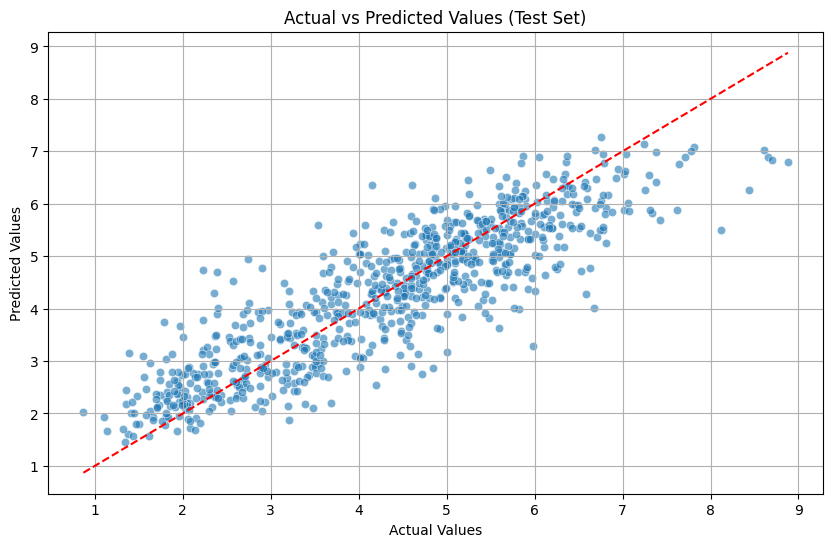

<Figure size 1200x800 with 0 Axes>

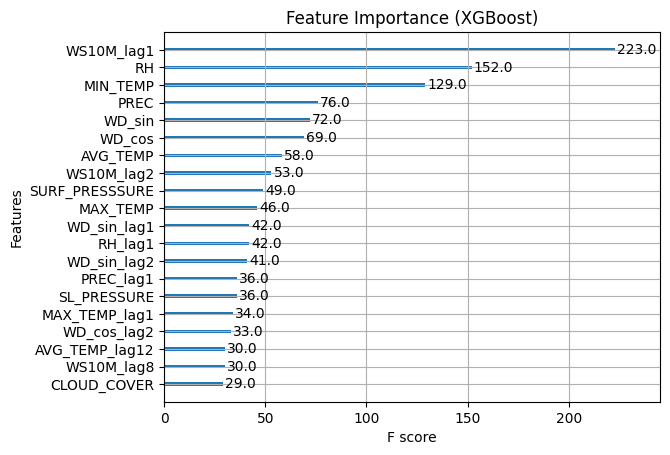


Top 20 Most Important Features:
            Feature  Importance
21       WS10M_lag1       223.0
4                RH       152.0
3          MIN_TEMP       129.0
0              PREC        76.0
8            WD_sin        72.0
9            WD_cos        69.0
5          AVG_TEMP        58.0
34       WS10M_lag2        53.0
1    SURF_PRESSSURE        49.0
2          MAX_TEMP        46.0
22      WD_sin_lag1        42.0
17          RH_lag1        42.0
35      WD_sin_lag2        41.0
13        PREC_lag1        36.0
6       SL_PRESSURE        36.0
15    MAX_TEMP_lag1        34.0
36      WD_cos_lag2        33.0
149  AVG_TEMP_lag12        30.0
104      WS10M_lag8        30.0
7       CLOUD_COVER        29.0


In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Define your best parameters
best_params = {
    'n_estimators': 250,
    'max_depth': 4,
    'learning_rate': 0.05289589726458591,
    'min_child_weight': 3,
    'gamma': 0.08356728812052798,
    'subsample': 0.7185372107290527,
    'objective': 'reg:squarederror',
    'random_state': 42
}

#Best Parameters: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.05289589726458591, 'min_child_weight': 3, 'gamma': 0.08356728812052798, 'subsample': 0.7185372107290527}

# Initialize and train the model with best parameters
best_xgb = xgb.XGBRegressor(**best_params)
best_xgb.fit(X_train, y_train)

# Make predictions
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

# Calculate evaluation metrics
def calculate_metrics(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"\n{set_name} Metrics:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"R-squared: {r2:.4f}")

    return mse, mae, rmse, mape, r2

# Calculate metrics for train and test sets
train_metrics = calculate_metrics(y_train, y_train_pred, "Train")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test")

# Plot actual vs predicted values for test set
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Test Set)')
plt.grid(True)
plt.show()

# Feature importance plot
plt.figure(figsize=(12, 8))
xgb.plot_importance(best_xgb, max_num_features=20)  # Show top 20 features
plt.title('Feature Importance (XGBoost)')
plt.show()

# Get feature importance scores and sort them
feature_importance = best_xgb.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'Feature': list(feature_importance.keys()),
    'Importance': list(feature_importance.values())
}).sort_values('Importance', ascending=False)

# Print top features
print("\nTop 20 Most Important Features:")
print(importance_df.head(20))

# Optionally, you can select top N features and retrain the model
# top_features = importance_df.head(30)['Feature'].values
# X_train_reduced = X_train[top_features]
# X_test_reduced = X_test[top_features]

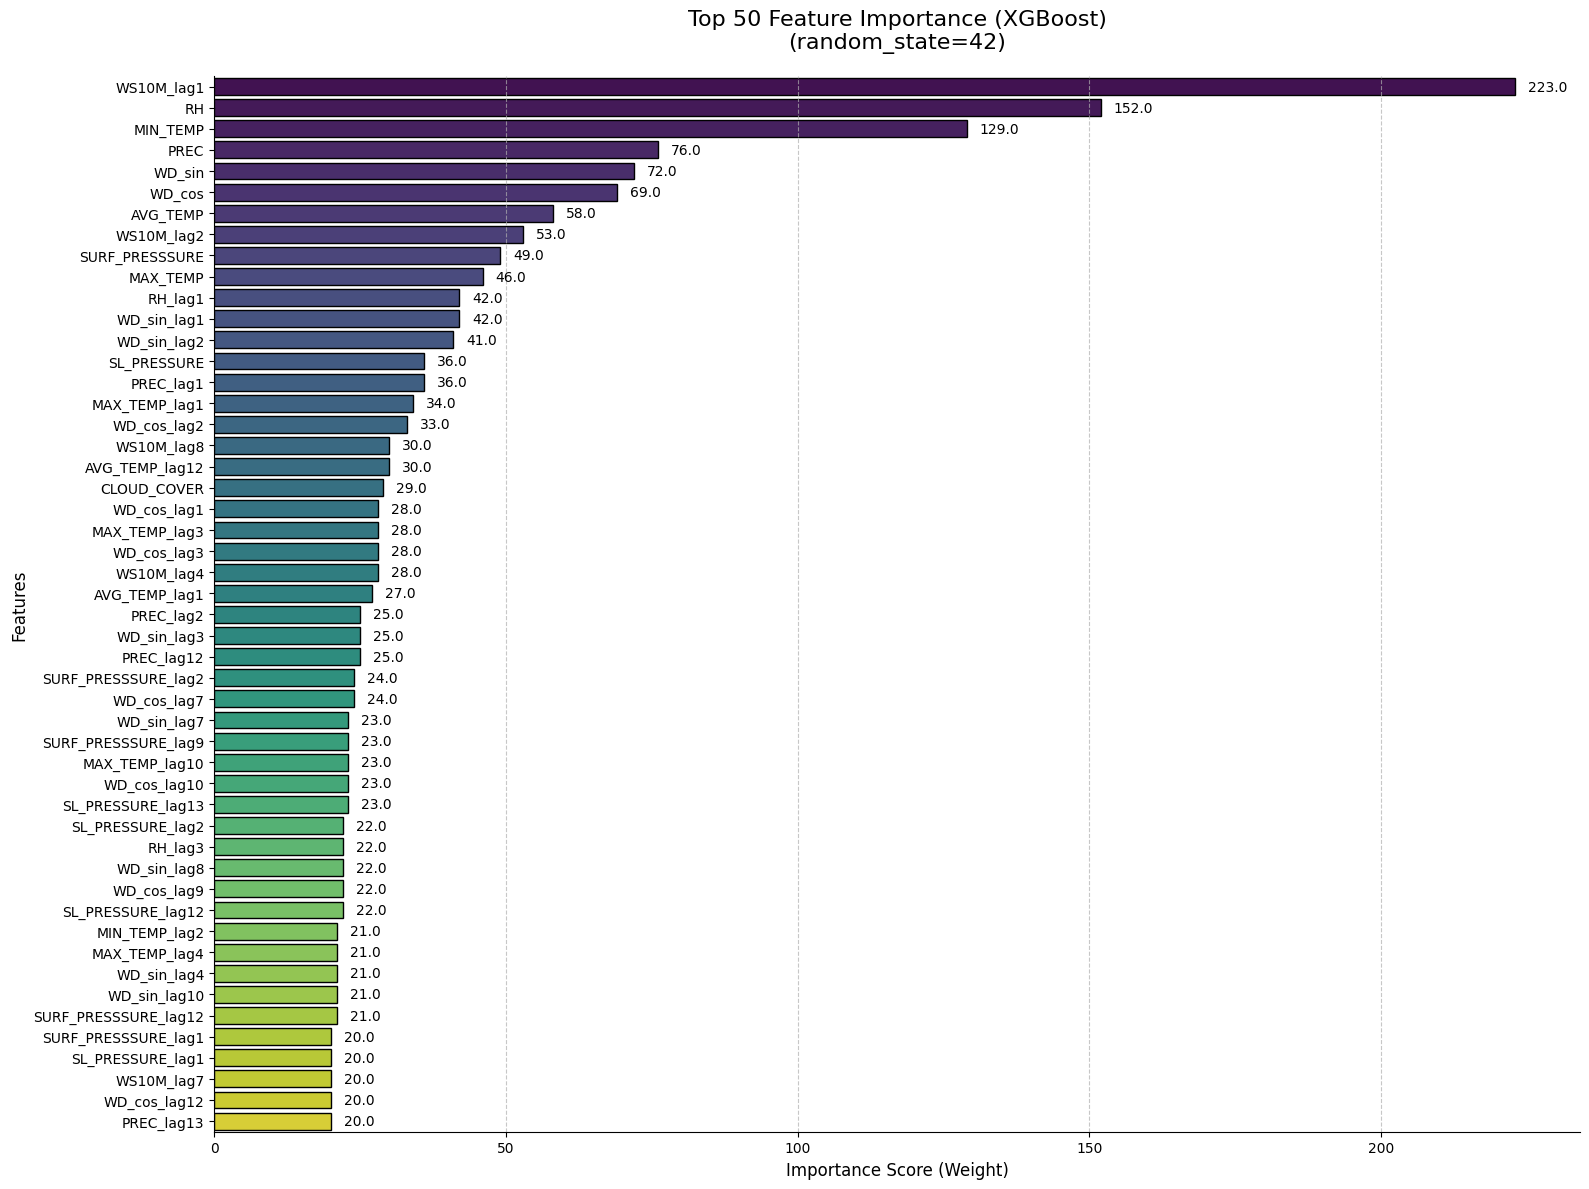

In [ ]:
import numpy as np
import random

# Set random seeds for full reproducibility
random.seed(42)
np.random.seed(42)

# Enhanced Feature Importance Plot (Seaborn) - Descending Order
plt.figure(figsize=(16, 12))

# Get feature importance
importance = best_xgb.get_booster().get_score(importance_type='weight')
importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:50]  # Top 50 features

# Create dataframe for plotting (sorted in DESCENDING order)
df_importance = pd.DataFrame(importance, columns=['Feature', 'Importance'])
df_importance = df_importance.sort_values('Importance', ascending=False)

# Create the plot (now in correct order)
ax = sns.barplot(x='Importance',
                 y='Feature',
                 data=df_importance,
                 palette='viridis',
                 edgecolor='black',
                 order=df_importance['Feature'])  # Explicit order control

# Add value labels
for i, (_, row) in enumerate(df_importance.iterrows()):
    ax.text(row['Importance'] + max(df_importance['Importance'])*0.01,
            i,
            f"{row['Importance']:.1f}",
            va='center',
            fontsize=10)

# Customize plot
plt.title('Top 50 Feature Importance (XGBoost)\n(random_state=42)', fontsize=16, pad=20)
plt.xlabel('Importance Score (Weight)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                            mean_absolute_percentage_error, r2_score)

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

def cross_validate_model(X, y, selected_features):
    X_selected = X[selected_features]
    model = RandomForestRegressor(random_state=SEED)
    tscv = TimeSeriesSplit(n_splits=5)

    mse_scores, rmse_scores, mae_scores, mape_scores, r2_scores = [], [], [], [], []

    for train_index, test_index in tscv.split(X_selected):
        X_train, X_test = X_selected.iloc[train_index], X_selected.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse_scores.append(mean_squared_error(y_test, y_pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        mape_scores.append(mean_absolute_percentage_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))

    return (np.mean(mse_scores), np.mean(rmse_scores),
            np.mean(mae_scores), np.mean(mape_scores),
            np.mean(r2_scores))

# Initialize all results dictionaries
results_mse, results_rmse, results_mae, results_mape, results_r2 = {}, {}, {}, {}, {}

# Test different numbers of top features
top_features_counts = [1, 2, 3, 6, 7, 10, 13, 15, 17, 20, 24, 25, 28]

for n in top_features_counts:
    selected_features = df_importance.head(n)['Feature']
    mse, rmse, mae, mape, r2 = cross_validate_model(df.drop(columns=['WS10M']), y, selected_features)

    results_mse[n] = mse
    results_rmse[n] = rmse
    results_mae[n] = mae
    results_mape[n] = mape
    results_r2[n] = r2

# Extract values for plotting
feature_counts = list(results_mse.keys())
mse_values = [results_mse[n] for n in feature_counts]
rmse_values = [results_rmse[n] for n in feature_counts]
mae_values = [results_mae[n] for n in feature_counts]
mape_values = [results_mape[n] for n in feature_counts]
r2_values = [results_r2[n] for n in feature_counts]

# Create figure
fig, axs = plt.subplots(3, 2, figsize=(16, 14))

# Plot metrics
axs[0, 0].plot(feature_counts, mse_values, marker='o', color='b')
axs[0, 0].set_title('Mean Squared Error (MSE)')
axs[0, 1].plot(feature_counts, rmse_values, marker='o', color='g')
axs[0, 1].set_title('Root Mean Squared Error (RMSE)')
axs[1, 0].plot(feature_counts, mae_values, marker='o', color='r')
axs[1, 0].set_title('Mean Absolute Error (MAE)')
axs[1, 1].plot(feature_counts, mape_values, marker='o', color='purple')
axs[1, 1].set_title('Mean Absolute Percentage Error (MAPE)')

# R-squared plot
axs[2, 0].plot(feature_counts, r2_values, marker='o', color='orange')
axs[2, 0].set_title('R-squared (R²)')
axs[2, 0].set_ylim([0, 1])

# Hide empty subplot
axs[2, 1].axis('off')

# Formatting
for ax in axs.flat:
    if ax.get_visible():
        ax.set_xlabel('Number of Top Features')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xticks(feature_counts)

plt.tight_layout()
plt.show()

In [ ]:
# Get the top 9 most important features
top_9_features = df_importance.head(15)['Feature'].tolist()

# Filter your datasets to only include these top features
X_train_reduced = X_train[top_9_features]
X_test_reduced = X_test[top_9_features]

# Verify the shape
print(f"Original training shape: {X_train.shape}")
print(f"Reduced training shape: {X_train_reduced.shape}")
print("\nTop 9 Features:")
print(top_9_features)

# You can now use these reduced datasets for:
# 1. Model training
best_xgb_reduced = xgb.XGBRegressor(**best_params)
best_xgb_reduced.fit(X_train_reduced, y_train)

# 2. Evaluation
y_test_pred_reduced = best_xgb_reduced.predict(X_test_reduced)
test_r2_reduced = r2_score(y_test, y_test_pred_reduced)
print(f"\nTest R-squared with top 9 features: {test_r2_reduced:.4f}")

# 3. Visualization (feature importance for just these 9 features)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=df_importance.head(15),
            palette='viridis',
            edgecolor='black')
plt.title('Top 9 Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
sns.despine()
plt.tight_layout()
plt.show()

# 4. Cross-validation (using your existing function)
mse, rmse, mae, mape, r2 = cross_validate_model(
    pd.concat([X_train, X_test]),  # Combined data
    pd.concat([y_train, y_test]),  # Combined targets
    top_9_features
)
print(f"\nCross-validated metrics with top 9 features:")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Get predictions using top 9 features
y_train_pred = best_xgb_reduced.predict(X_train_reduced)
y_test_pred = best_xgb_reduced.predict(X_test_reduced)

# Calculate metrics for training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mape = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
train_r2 = r2_score(y_train, y_train_pred)

# Calculate metrics for test set
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
test_r2 = r2_score(y_test, y_test_pred)

# Print metrics in a formatted table
print("\nEvaluation Metrics (Top 9 Features)")
print("+" + "-"*50 + "+")
print("| {:^20} | {:^12} | {:^12} |".format("Metric", "Train", "Test"))
print("+" + "-"*50 + "+")
print("| {:20} | {:12.4f} | {:12.4f} |".format("MSE", train_mse, test_mse))
print("| {:20} | {:12.4f} | {:12.4f} |".format("RMSE", train_rmse, test_rmse))
print("| {:20} | {:12.4f} | {:12.4f} |".format("MAE", train_mae, test_mae))
print("| {:20} | {:12.4f}% | {:12.4f}% |".format("MAPE", train_mape, test_mape))
print("| {:20} | {:12.4f} | {:12.4f} |".format("R-squared", train_r2, test_r2))
print("+" + "-"*50 + "+")

# Additional interpretation
print("\nModel Performance Interpretation:")
print(f"- R-squared: {test_r2:.3f} (1 is perfect, 0 is baseline)")
print(f"- RMSE: {test_rmse:.3f} (same units as target variable)")
print(f"- MAPE: {test_mape:.3f}% (percentage error)")


#['WS10M_lag1', 'PREC', 'RH', 'MIN_TEMP', 'MAX_TEMP', 'WD_sin', 'SURF_PRESSSURE', 'WD_cos', 'AVG_TEMP', 'WS10M_lag2', 'PREC_lag1', 'SL_PRESSURE']

In [ ]:
# INSTALLING **PACKAGES**


!pip install statsmodels

! pip install optuna

!pip install tabulate

# Standard libraries
import sys  # System-specific parameters and functions
import os   # Miscellaneous operating system interfaces
import warnings  # Warning control
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical operations

# Visualization
import matplotlib.pyplot as plt  # Plotting library
import seaborn as sns  # Statistical data visualization
from matplotlib.colors import ListedColormap  # Colormap utilities

# Model Helpers
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler  # Preprocessing tools
from sklearn import model_selection, metrics, preprocessing  # Model selection, evaluation, and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV  # Model selection and evaluation
from sklearn.tree import DecisionTreeClassifier  # Decision tree classifier


# Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor  # Variance inflation factor
from scipy.stats import pointbiserialr, chi2_contingency, spearmanr, entropy  # Statistical functions
from statsmodels.graphics.gofplots import qqplot  # Q-Q plot
from collections import Counter  # Container datatypes

# Tabulate
from tabulate import tabulate  # Pretty-print tabular data

# Set visualization style
#sns.set()  # Set Seaborn default style
#plt.style.use('ggplot')  # Set ggplot style for matplotlib



# LOADING THE DATA SET
#https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
#https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing
import gdown
import pandas as pd


# Read Xlsx file
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import pandas as pd
import numpy as np  # Ensure numpy is imported
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Read Xlsx file
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import pandas as pd
import numpy as np  # Ensure numpy is imported
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


import pandas as pd

# Updated Google Sheets link setup
sheet_id = "1j_Euo80PrGckVDVr2hTG9zZebxJD0TSC"
sheet_name = "Sheet1"  # Update this if the sheet name is different

# Generate the CSV export link
csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

# Read the Google Sheet as CSV
df = pd.read_csv(csv_url)

# Backup original DataFrame
df_backup = df.copy()


# Set Date as the index
df = df.set_index('Date')

# Display the DataFrame (optional in scripts)
df.head()
df_backup=df.copy()



monsoon_cols=['MONOSOON_SEASON_Northeast_Monsoon',
       'MONOSOON_SEASON_Second_Inter_Monsoon',
       'MONOSOON_SEASON_Southwest_Monsoon']
df[monsoon_cols]=df[monsoon_cols].astype(int)

# Define the number of lag terms
num_lags = 2

# Columns to exclude from lagging
exclude_cols = ["YEAR", "MO", "DY"]

# Create lag features for each column except excluded ones
lagged_df = df.copy()
for lag in range(1, num_lags + 1):
    # Only shift columns that aren't in exclude_cols
    cols_to_lag = [col for col in df.columns if col not in exclude_cols]
    lagged_features = df[cols_to_lag].shift(lag).add_suffix(f'_lag{lag}')
    lagged_df = pd.concat([lagged_df, lagged_features], axis=1)

# Drop rows with NaN values (since initial lags will have missing values)
lagged_df = lagged_df.dropna()

# Verify the results
print("Original columns:", df.columns.tolist())
print("\nNew columns with lags:", [col for col in lagged_df.columns if '_lag' in col])
print("\nExcluded columns from lagging:", exclude_cols)


# Display the first few rows
print(lagged_df.head())
lagged_df
df = lagged_df
df

In [ ]:
# Get top 15 important features (excluding temporal columns)
top_15_features = df_importance.head(15)['Feature'].tolist()

# Add temporal columns to keep (note: no spaces in column names!)
selected_features = top_15_features + ["YEAR", "MO", "DY","WS10M"]

# Select these columns from your DataFrame
filtered_df = df[selected_features].copy()


In [ ]:
# Save to CSV
filtered_df.to_csv('ImportantFeaturelag14.csv', index=False)

print(f"DataFrame saved as 'ImportantFeaturelag14.csv' with {len(lagged_df.columns)} columns")